# Analiza jakości danych w systemie

## 1. Wprowadzenie

### 1.1 Cel analizy

Celem niniejszej analizy jest ocena jakości danych zgromadzonych w hurtowni oraz identyfikacja potencjalnych problemów mogących wpłynąć na wiarygodność prowadzonych analiz.

### 1.2 Zakres analizy

Analiza obejmuje dane z sezonów 2007/2008 - 2025/2026, z 50 lig piłkarskich z 25 krajów. Sezon 2025/2026 jest traktowany jako sezon bieżący i nie jest uwzględniany w analizach kompletności.

### 1.3 Metodologia

Przedstawione analizy opierają się na danych pobranych zarówno ze znormalizowanej części hurtowni jak i w niektórych przypadkach z systemu źródłowego. Do weryfikacji jakości wykorzystano zestaw metryk obejmujących kompletność, spójność oraz poprawność danych.

### 1.4 Konfiguracja

In [192]:
from sqlalchemy import create_engine
import urllib
from sqlalchemy import inspect
import pandas as pd
import os
import seaborn as sns
import matplotlib.pyplot as plt

In [193]:
sns.set_palette("deep")

In [194]:
params = urllib.parse.quote_plus(
    "DRIVER={ODBC Driver 18 for SQL Server};"
    "SERVER=127.0.0.1,1433;"
    "DATABASE=LEAGUE_DB;"
    "UID=sa;"
    "PWD=YourStrongPassword1!;"
    "TrustServerCertificate=yes;"
)

source_engine = create_engine(
    f"mssql+pyodbc:///?odbc_connect={params}",
    fast_executemany=True
)

source_inspector = inspect(source_engine)

In [ ]:
tables = source_inspector.get_table_names()
tables
# t = pd.read_sql('SELECT TOP(20) * FROM dbo.T_DIM_Venue;', source_engine)
# t

,VenueSK,VenueName,Location,City,Capacity,EffectiveStartDate,EffectiveEndDate,IsCurrent
0,-1,Unknown,Unknown,Unknown,0.0,1900-01-01 00:00:00.000,9999-12-31 00:00:00,True
1,1,Stadion Polonii im. generała Kazimierza Sosnko...,"ul. Konwiktorska 6, Warszawa",Unknown,NaN,2025-12-28 12:43:37.110,9999-12-31 00:00:00,True
2,2,Stadion Miejski Widzewa Łódź (Łódź),None,Łódź,NaN,2025-12-28 12:43:37.110,9999-12-31 00:00:00,True
3,3,Ewood Park,"Nuttall Street, Blackburn, Lancashire",Unknown,NaN,2025-12-28 12:43:37.110,9999-12-31 00:00:00,True
4,4,Gradski Stadion (Senta),None,Senta,NaN,2025-12-28 12:43:37.110,9999-12-31 00:00:00,True
5,5,Stadion Šubićevac (Šibenik),None,Šibenik,NaN,2025-12-28 12:43:37.110,9999-12-31 00:00:00,True
6,6,Tofiq Bəhramov adına Respublika stadionu,"Xoyski küçəsi 98 A, Baku",Unknown,NaN,2025-12-28 12:43:37.110,9999-12-31 00:00:00,True
7,7,Estádio José Alvalade (Lisboa),None,Lisboa,NaN,2025-12-28 12:43:37.110,9999-12-31 00:00:00,True
8,8,Stadionul Municipal (Turnu Măgurele),None,Turnu Măgurele,NaN,2025-12-28 12:43:37.110,9999-12-31 00:00:00,True
9,9,Stadio Carlo Castellani,"Viale delle Olimpiadi, Empoli",Unknown,NaN,2025-12-28 12:43:37.110,9999-12-31 00:00:00,True


In [196]:
destination_engine = create_engine(f"postgresql+psycopg2://{os.environ['POSTGRES_USER']}:" \
    f"{os.environ['POSTGRES_PASSWORD']}@localhost:{os.environ['POSTGRES_PORT']}" \
    f"/{os.environ['POSTGRES_DB']}"
)

## 2. Kompletność danych historycznych

### 2.1 Ogólna charakterystyka zbioru danych

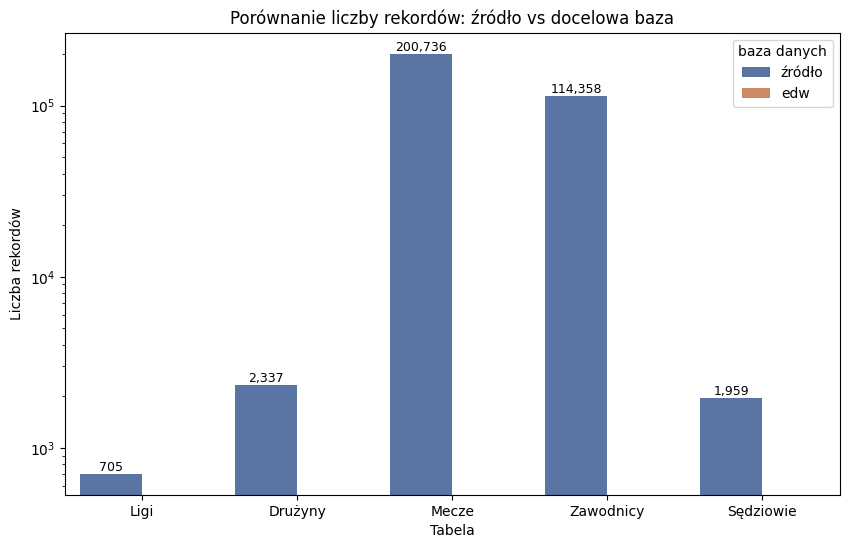

In [197]:
sl_query = 'SELECT COUNT(*) FROM dbo.T_DIM_League;'
sl_df = pd.read_sql(sl_query, source_engine)
sl_count = sl_df.iloc[0, 0]

dl_query = 'SELECT COUNT(*) FROM core.leagues;'
dl_df = pd.read_sql(dl_query, destination_engine)
dl_count = dl_df.iloc[0, 0]

sm_query = 'SELECT COUNT(*) FROM dbo.T_F_Match_Stats;'
sm_df = pd.read_sql(sm_query, source_engine)
sm_count = sm_df.iloc[0, 0]

dm_query = 'SELECT COUNT(*) FROM core.matches;'
dm_df = pd.read_sql(dm_query, destination_engine)
dm_count = dm_df.iloc[0, 0]

st_query = 'SELECT COUNT(*) FROM dbo.T_DIM_Team;'
st_df = pd.read_sql(st_query, source_engine)
st_count = st_df.iloc[0, 0]

dt_query = 'SELECT COUNT(*) FROM core.matches;'
dt_df = pd.read_sql(dt_query, destination_engine)
dt_count = dt_df.iloc[0, 0]

sp_query = 'SELECT COUNT(*) FROM dbo.T_DIM_Player;'
sp_df = pd.read_sql(sp_query, source_engine)
sp_count = sp_df.iloc[0, 0]

dp_query = 'SELECT COUNT(*) FROM core.players;'
dp_df = pd.read_sql(dp_query, destination_engine)
dp_count = dp_df.iloc[0, 0]

sr_query = 'SELECT COUNT(*) FROM dbo.T_DIM_Referees;'
sr_df = pd.read_sql(sr_query, source_engine)
sr_count = sr_df.iloc[0, 0]

dr_query = 'SELECT COUNT(*) FROM core.referees;'
dr_df = pd.read_sql(dr_query, destination_engine)
dr_count = dr_df.iloc[0, 0]

plot_df = pd.DataFrame([
    { 
        "tabela": "Ligi",
        "źródło": sl_count,
        "edw": dl_count
    },
    { 
        "tabela": "Drużyny",
        "źródło": st_count,
        "edw": dt_count
    },
    { 
        "tabela": "Mecze",
        "źródło": sm_count,
        "edw": dm_count
    },
    { 
        "tabela": "Zawodnicy",
        "źródło": sp_count,
        "edw": dp_count
    },
    { 
        "tabela": "Sędziowie",
        "źródło": sr_count,
        "edw": dr_count
    }
])

plot_long = plot_df.melt(id_vars="tabela", value_vars=["źródło", "edw"], 
                         var_name="baza danych", value_name="liczba_rekordów")

plt.figure(figsize=(10,6))
ax = sns.barplot(data=plot_long, x="tabela", y="liczba_rekordów", hue="baza danych")
plt.yscale("log")

for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{int(height):,}', 
                (p.get_x() + p.get_width() / 2., height),
                ha='center', va='bottom', fontsize=9, rotation=0)

plt.title("Porównanie liczby rekordów: źródło vs docelowa baza")
plt.ylabel("Liczba rekordów")
plt.xlabel("Tabela")
plt.show()


In [198]:
source_date_range_query = """
SELECT 
    MIN(DateSK) AS source_min_date, 
    MAX(DateSK) AS source_max_date
FROM 
    dbo.T_F_Match_Stats;
"""
sdr_df = pd.read_sql(source_date_range_query, source_engine)

destination_date_range_query = """
SELECT 
    MIN(date) AS destination_min_date, 
    MAX(date) AS destination_max_date
FROM 
    core.matches;
"""
ddr_df = pd.read_sql(destination_date_range_query, destination_engine)

df = pd.concat([sdr_df, ddr_df], axis=1)
df


,source_min_date,source_max_date,destination_min_date,destination_max_date
0,19000101,19000101,None,None


In [ ]:
source_unique_seasons = """
SELECT 
    COUNT(DISTINCT(SeasonSK)) AS source_season_count
FROM 
    dbo.T_F_Match_Stats;
""" 
sus_df = pd.read_sql(source_unique_seasons, source_engine)

destination_unique_seasons = """
SELECT 
    COUNT(*) AS destination_season_count
FROM 
    core.seasons;
""" 
dus_df = pd.read_sql(destination_unique_seasons, destination_engine)


df = pd.DataFrame({
    "source_season_count": [sus_df.iloc[0, 0]],
    "destination_season_count": [dus_df.iloc[0, 0]],
})
df

,source_season_count,destination_season_count
0,36,21


In [200]:
source_unique_leagues = """
SELECT 
    COUNT(DISTINCT(LeagueName)) AS source_unique_leagues_count
FROM 
    dbo.T_DIM_League;
""" 
sul_df = pd.read_sql(source_unique_leagues, source_engine)

destination_unique_leagues = """
SELECT 
    COUNT(*) AS destination_unique_leagues_count
FROM 
    core.leagues;
""" 
dul_df = pd.read_sql(destination_unique_leagues, destination_engine)

df = pd.DataFrame({
    "source_unique_leagues_count": [sul_df.iloc[0, 0]],
    "destination_unique_leagues_count": [dul_df.iloc[0, 0]],
})
df

,source_unique_leagues_count,destination_unique_leagues_count
0,26,0


### 2.2 Pokrycie sezonów

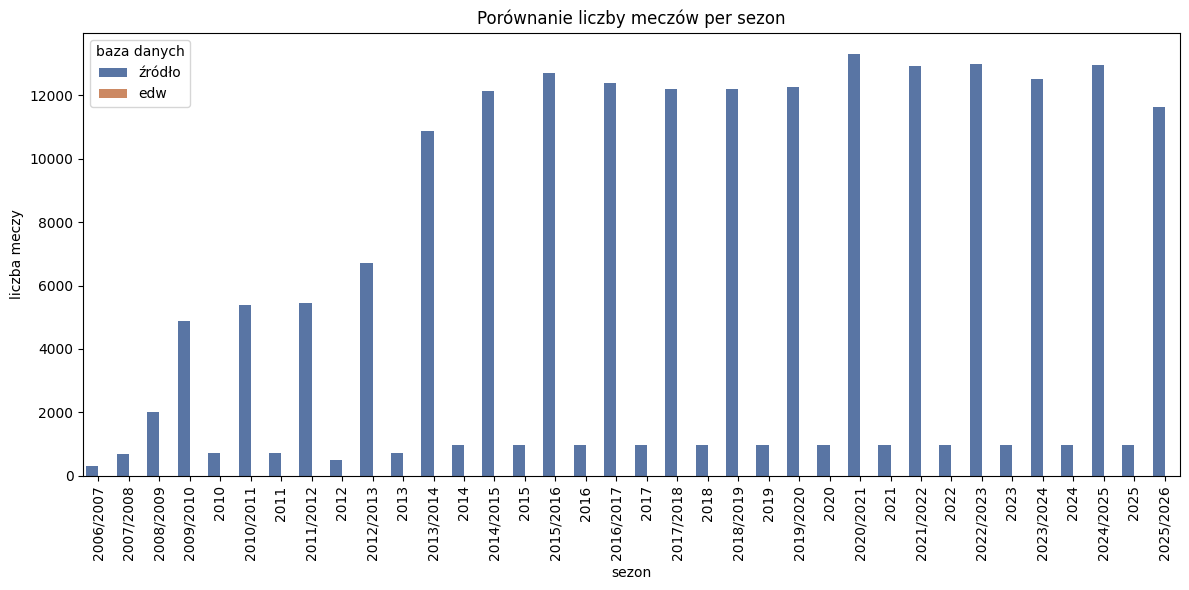

In [201]:
source_matches_per_season = """
    SELECT 
        s.SeasonName AS sezon,
        COUNT(ms.MatchSK) AS źródło
    FROM
        dbo.T_F_Match_Stats ms
    JOIN 
        dbo.T_DIM_Season s ON ms.SeasonSK = s.SeasonSK
    GROUP BY
        s.SeasonName;
"""
smps_df = pd.read_sql(source_matches_per_season, source_engine)

destination_matches_per_season = """
    SELECT 
        s.name AS sezon,
        COUNT(m.match_id) AS edw
    FROM
        core.matches m
    JOIN 
        core.seasons s ON s.season_id = m.season_id 
    GROUP BY
        s.name;
"""
dmps_df = pd.read_sql(destination_matches_per_season, destination_engine)

df = pd.merge(smps_df, dmps_df, on="sezon", how="outer")

plot_df = df.melt(id_vars="sezon", value_vars=["źródło", "edw"], 
                  var_name="baza danych", value_name="liczba meczy")

plt.figure(figsize=(12,6))
sns.barplot(data=plot_df, x="sezon", y="liczba meczy", hue="baza danych")
plt.xticks(rotation=90)
plt.title("Porównanie liczby meczów per sezon")
plt.tight_layout()
plt.show()


### 2.3 Pokrycie lig

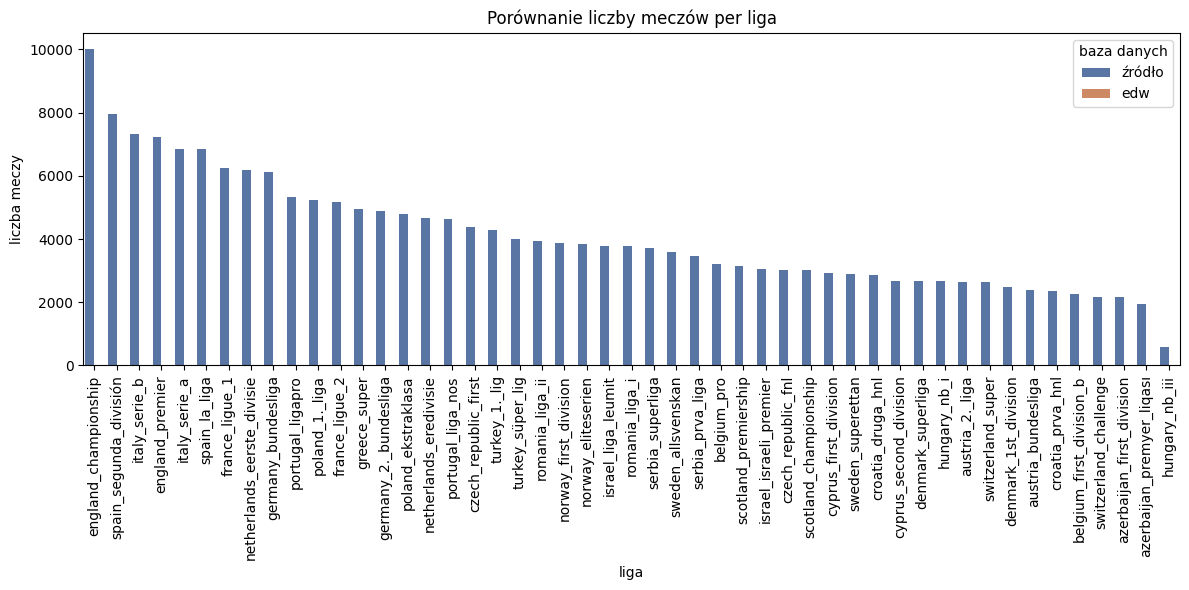

In [210]:
source_matches_per_league = """
    SELECT 
        ln.League_name AS liga,
        COUNT(m.MatchSK) AS źródło
    FROM
        dbo.T_F_Match_Stats m
    JOIN
        dbo.T_DIM_League l ON l.League_id = m.competition_id
    JOIN
        dbo.T_DIM_League_name ln ON ln.competition_id = m.competition_id
    GROUP BY
        ln.League_name;
"""
smpl_df = pd.read_sql(source_matches_per_league, source_engine)

destination_matches_per_league = """
    SELECT 
        l.name AS liga,
        COUNT(m.match_id) AS edw
    FROM
        core.matches m
    JOIN 
        core.seasons s ON s.season_id = m.season_id
    JOIN
        core.leagues_seasons ls ON ls.season_id = s.season_id
    JOIN
        core.leagues l ON l.league_id = ls.league_id
    GROUP BY
        l.name;
"""
dmpl_df = pd.read_sql(destination_matches_per_league, destination_engine)

df = pd.merge(smpl_df, dmpl_df, on="liga", how="outer")

plot_df = df.melt(id_vars="liga", value_vars=["źródło", "edw"], 
                  var_name="baza danych", value_name="liczba meczy")

league_order = (
    df.sort_values("źródło", ascending=False)["liga"]
)

plt.figure(figsize=(12,6))
sns.barplot(data=plot_df, x="liga", y="liczba meczy", hue="baza danych", order=league_order)
plt.xticks(rotation=90)
plt.title("Porównanie liczby meczów per liga")
plt.tight_layout()
plt.show()